Ce code permet de calculer les espacements moyens et les tailles des motifs pour une image de type .tif traitée sous imageJ. 

Pour calculer l'espacement moyen, il faut en entrée un fichier Csv de mesure sur un nuage de points, avec X, Y les coordonnées des points correspondant au milieu des motifs. 

Pour calculer la taille moyenne il faut en entrée un fichier csv de mesure sur des ovales, entourant les motifs, l'aire moyenne de ces ovales permet d'obtenir un diametre équivalent des motifs.  

Ce programme permet à la fois de traiter des données experimentales 2D ou l'espacement moyen est l'espacement entre premiers voisins et en 1D ou l'espacement moyen est la distance entre chaque motif

Attention lors de l'utilisation de ce programme aux unitées et aux échelles. 

# CAS 1D


Nombre de motifs : 34
TAILLE DES MOTIFS

Diamètre équivalent moyen :
  194.16 um
  écart-type = 39.12 um

Espacement moyen :
  332.11 um
Écart-type :77.83 um


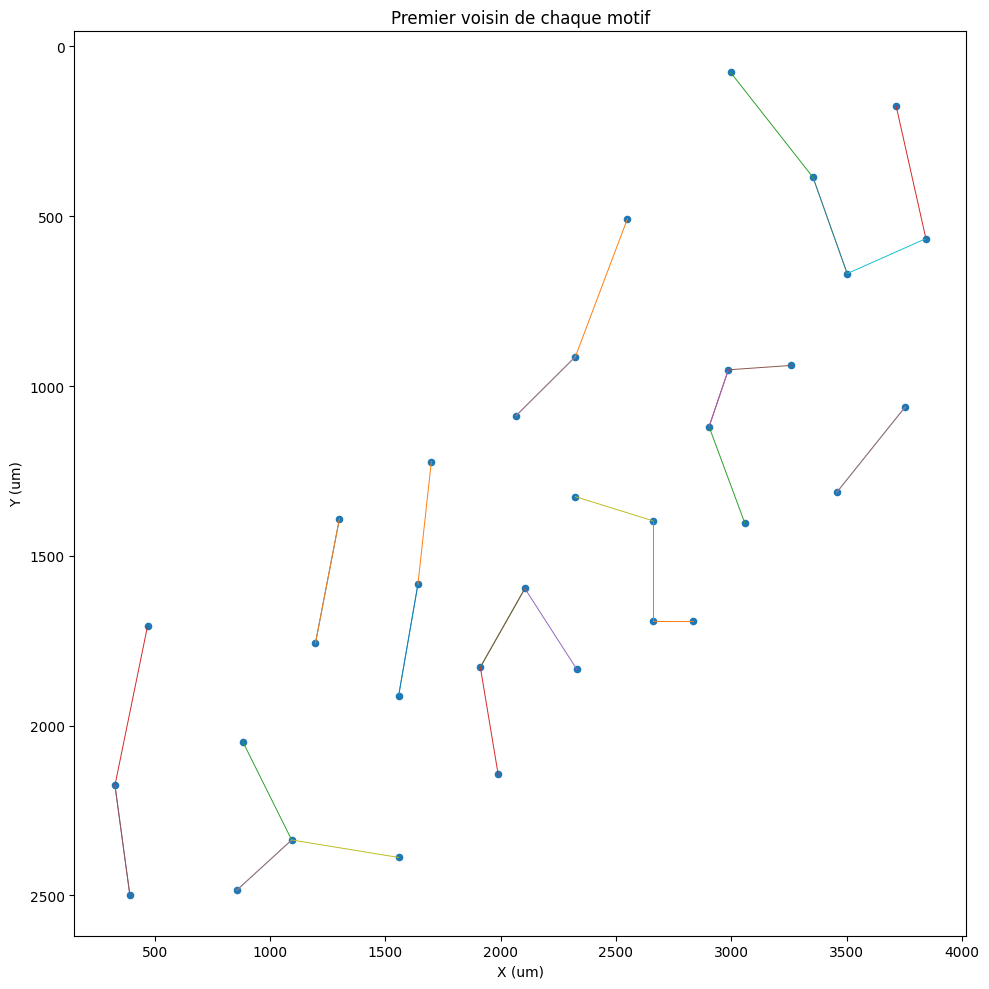

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# Modifier les noms des fichiers si nécessaire
fichier_points = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Results.csv"
fichier_ovales = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Resultscercles.csv"

points = pd.read_csv(fichier_points)
ovales = pd.read_csv(fichier_ovales)




# Diamètre équivalent à partir de l'aire
# D_eq = 2 * sqrt(A/pi)
diametre_equivalent = 2 * np.sqrt(ovales["Area"] / np.pi)
print(f"\nNombre de motifs : {len(points)}")
print("TAILLE DES MOTIFS")

print(f"\nDiamètre équivalent moyen :")
print(f"  {diametre_equivalent.mean():.2f} um")
print(f"  écart-type = {diametre_equivalent.std():.2f} um")



# Coordonnées des centres
xy = points[["X", "Y"]].values

# Création de l'arbre de recherche
tree = cKDTree(xy)

# k=2 :
#   résultat 0 = le point lui-même
#   résultat 1 = son premier voisin
distances, indices = tree.query(xy, k=2)

# Distance vers le premier voisin
premier_voisin = distances[:, 1]


print(f"\nEspacement moyen :")
print(f"  {premier_voisin.mean():.2f} um")

print(f"Écart-type :{premier_voisin.std():.2f} um")




image = None

plt.figure(figsize=(10, 10))

if image is not None:
    plt.imshow(image, cmap="gray")

# Affichage des centres
plt.scatter(
    xy[:, 0],
    xy[:, 1],
    s=20
)

# Tracé des connexions vers le premier voisin
for i, (x, y) in enumerate(xy):

    j = indices[i, 1]

    x2, y2 = xy[j]

    plt.plot(
        [x, x2],
        [y, y2],
        linewidth=0.7
    )

plt.xlabel("X (um)")
plt.ylabel("Y (um)")
plt.title("Premier voisin de chaque motif")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

C:\Users\lisab\AppData\Local\Temp\ipykernel_10460\3806899934.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


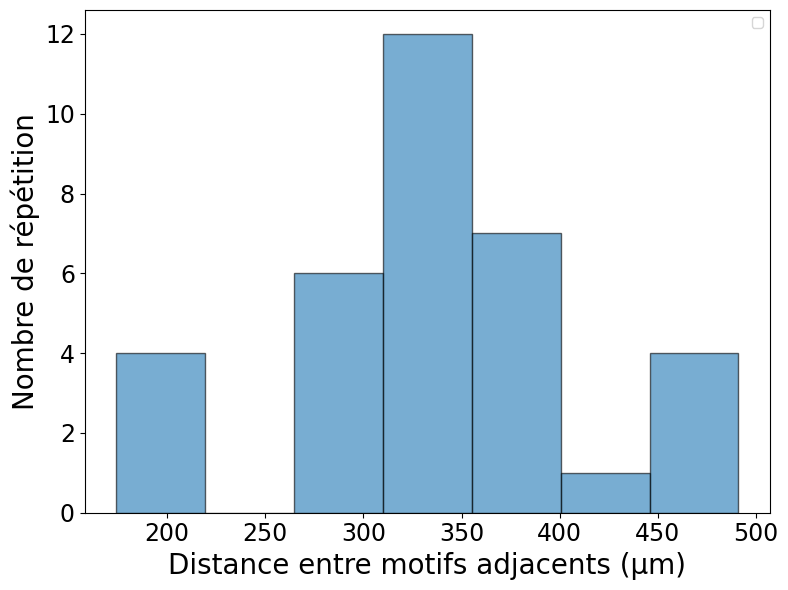

In [ ]:
# ============================================================
# HISTOGRAMME DES DISTANCES ENTRE MOTIFS ADJACENTS
# ============================================================

from scipy.stats import norm


# Moyenne et écart-type des distances
moyenne_distance = distances.mean()
ecart_type_distance = distances.std()


# Histogramme
plt.figure(figsize=(8, 6))

counts, bins, _ = plt.hist(
    premier_voisin,
    bins="auto",
    alpha=0.6,
    edgecolor="black",
    
)


plt.xlabel(
    "Distance entre motifs adjacents (µm)",
    fontsize=20
)

plt.ylabel(
    "Nombre de répétition",
    fontsize=20
)


plt.legend()
plt.tick_params(axis='both', labelsize=17)
plt.tight_layout()
plt.show()

In [ ]:
# CAS 2D


Nombre de motifs : 14
TAILLE DES MOTIFS

Diamètre équivalent moyen :
  160.96 um
  écart-type = 19.29 um

ESPACEMENT ENTRE MOTIFS ADJACENTS

Nombre de motifs : 14

Distances entre motifs :
  Motif 1 → Motif 2 : 963.14 µm
  Motif 2 → Motif 3 : 663.44 µm
  Motif 3 → Motif 4 : 737.97 µm
  Motif 4 → Motif 5 : 600.74 µm
  Motif 5 → Motif 6 : 319.84 µm
  Motif 6 → Motif 7 : 308.11 µm
  Motif 7 → Motif 8 : 585.25 µm
  Motif 8 → Motif 9 : 519.66 µm
  Motif 9 → Motif 10 : 433.36 µm
  Motif 10 → Motif 11 : 472.99 µm
  Motif 11 → Motif 12 : 367.13 µm
  Motif 12 → Motif 13 : 292.62 µm
  Motif 13 → Motif 14 : 445.23 µm

Espacement moyen :
  516.11 µm
Écart-type :
  186.13 µm


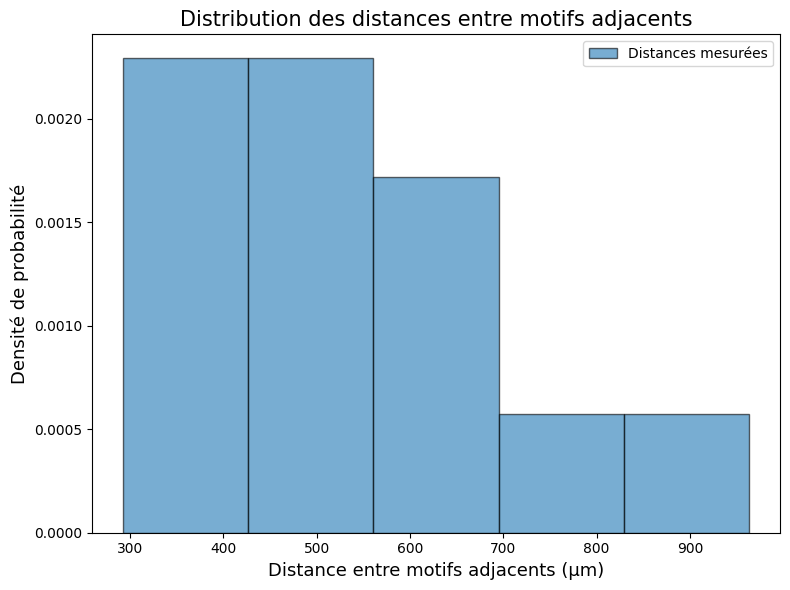

In [11]:

# Modifier les noms des fichiers si nécessaire
fichier_points = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Results1Dv.csv"
fichier_ovales = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Results1DCerclesV.csv"

points = pd.read_csv(fichier_points)
ovales = pd.read_csv(fichier_ovales)




# Diamètre équivalent à partir de l'aire
# D_eq = 2 * sqrt(A/pi)
diametre_equivalent = 2 * np.sqrt(ovales["Area"] / np.pi)
print(f"\nNombre de motifs : {len(points)}")
print("TAILLE DES MOTIFS")

print(f"\nDiamètre équivalent moyen :")
print(f"  {diametre_equivalent.mean():.2f} um")
print(f"  écart-type = {diametre_equivalent.std():.2f} um")

# ============================================================
# DISTANCE ENTRE MOTIFS ADJACENTS
# ============================================================

# Coordonnées des centres
xy = points[["X", "Y"]].values


# ------------------------------------------------------------
# Tri des motifs selon leur position sur l'axe X
# ------------------------------------------------------------

ordre = np.argsort(xy[:, 0])

xy_trie = xy[ordre]


# ------------------------------------------------------------
# Distance entre deux motifs successifs
# ------------------------------------------------------------

# Comme les motifs sont quasiment alignés,
# on calcule la distance euclidienne entre chaque
# motif et le motif immédiatement suivant.

dx = np.diff(xy_trie[:, 0])
dy = np.diff(xy_trie[:, 1])

distances = np.sqrt(dx**2 + dy**2)


# ------------------------------------------------------------
# Résultats
# ------------------------------------------------------------

print("\nESPACEMENT ENTRE MOTIFS ADJACENTS")

print(f"\nNombre de motifs : {len(xy_trie)}")

print(f"\nDistances entre motifs :")
for i, d in enumerate(distances):
    print(
        f"  Motif {i+1} → Motif {i+2} : "
        f"{d:.2f} µm"
    )

print("\nEspacement moyen :")
print(f"  {distances.mean():.2f} µm")

print("Écart-type :")
print(f"  {distances.std():.2f} µm")

# ============================================================
# HISTOGRAMME DES DISTANCES ENTRE MOTIFS ADJACENTS
# ============================================================

from scipy.stats import norm


# Moyenne et écart-type des distances
moyenne_distance = distances.mean()
ecart_type_distance = distances.std()


# Histogramme
plt.figure(figsize=(8, 6))

counts, bins, _ = plt.hist(
    distances,
    bins="auto",
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Distances mesurées"
)

# ============================================================
# MISE EN FORME
# ============================================================

plt.xlabel(
    "Distance entre motifs adjacents (µm)",
    fontsize=13
)

plt.ylabel(
    "Densité de probabilité",
    fontsize=13
)

plt.title(
    "Distribution des distances entre motifs adjacents",
    fontsize=15
)

plt.legend()

plt.tight_layout()
plt.show()

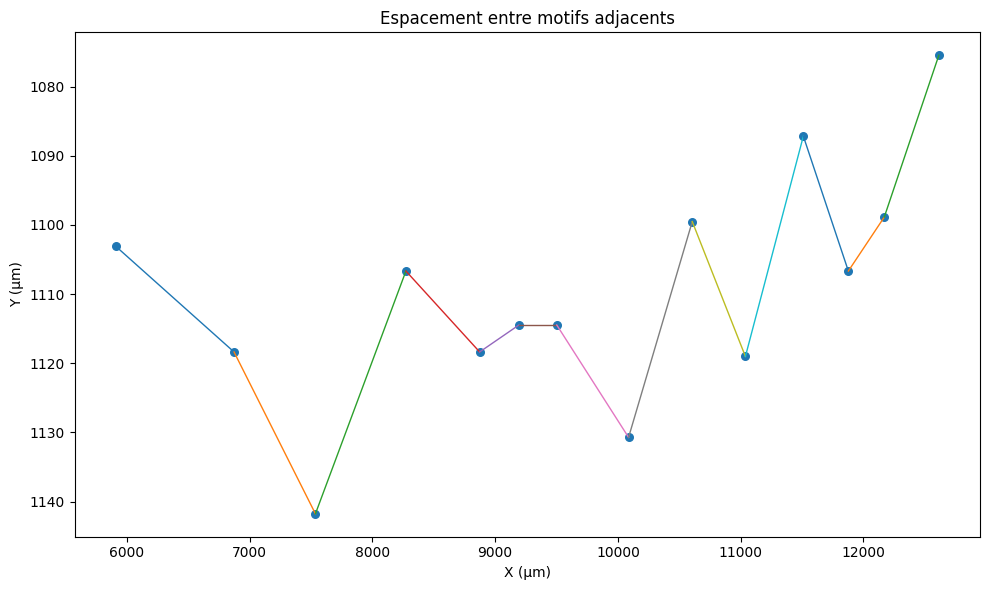

In [6]:
# ============================================================
# VISUALISATION DES MOTIFS ADJACENTS
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    xy_trie[:, 0],
    xy_trie[:, 1],
    s=30
)

# Relier uniquement les motifs adjacents
for i in range(len(xy_trie) - 1):

    plt.plot(
        [xy_trie[i, 0], xy_trie[i + 1, 0]],
        [xy_trie[i, 1], xy_trie[i + 1, 1]],
        linewidth=1
    )

plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")

plt.title(
    "Espacement entre motifs adjacents"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Le but est d'effectuer la même méthode de traitement sur un fichier mat qui provient des simulations. Cela permet de calculer la taille moyenne des motifs en 2D. 
Pour cela on traduit le ficher mat en tif pour l'ouvrir avec imageJ, on peut ensuite faire les mêmes étapes de traitement que pour l'image provenant du microscope. 

In [2]:
import scipy.io
import numpy as np
import tifffile
from pathlib import Path


def mat_to_tif(matfile, outputfile=None):

    data = scipy.io.loadmat(matfile)

    # Matrice de simulation
    N = data["Nsup"]

    # Conversion en float32
    N = np.asarray(N, dtype=np.float32)

    if outputfile is None:
        outputfile = (
            Path(matfile).with_suffix(".tif")
        )
    tifffile.imwrite(
        outputfile,
        N
    )

    print("Fichier créé :")
    print(outputfile)

    print("\nDimensions :", N.shape)
    print("Minimum :", N.min())
    print("Maximum :", N.max())

    return N


mat_to_tif("C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/CODE/LISA/2D_fig/mu_0.250_G_0.030_t_300000_cell_100000.mat")

Fichier créé :
C:\Users\lisab\OneDrive - INSA Toulouse\Documents\insa\stage 4A\CODE\LISA\2D_fig\mu_0.250_G_0.030_t_300000_cell_100000.tif

Dimensions : (81, 81)
Minimum : 3.84218e-10
Maximum : 1124548.1


array([[3.7425483e-08, 7.4216462e-07, 1.2579391e-05, ..., 7.7833125e-04,
        2.0050509e-03, 3.3089838e-03],
       [1.3655867e-06, 2.9956720e-05, 5.6079251e-04, ..., 3.7005436e-02,
        1.1119566e-01, 1.8493155e-01],
       [4.8249734e-05, 1.1849082e-03, 2.4867937e-02, ..., 2.0411098e+00,
        6.2805495e+00, 1.0517510e+01],
       ...,
       [2.0485680e+01, 1.2543990e+01, 4.2470188e+00, ..., 1.7616409e-03,
        3.1551848e-05, 5.7513313e-07],
       [3.6064196e-01, 2.2219792e-01, 7.6771028e-02, ..., 7.9131144e-04,
        1.4251397e-05, 2.6122731e-07],
       [6.4604492e-03, 4.0059807e-03, 1.4594176e-03, ..., 4.7555659e-04,
        8.5426509e-06, 1.5622749e-07]], dtype=float32)

TAILLE DES MOTIFS

Diamètre équivalent moyen :
  1.06 mm
  écart-type = 0.12 mm

Espacement moyen :
  1.65 mm
Écart-type = 0.21 mm 


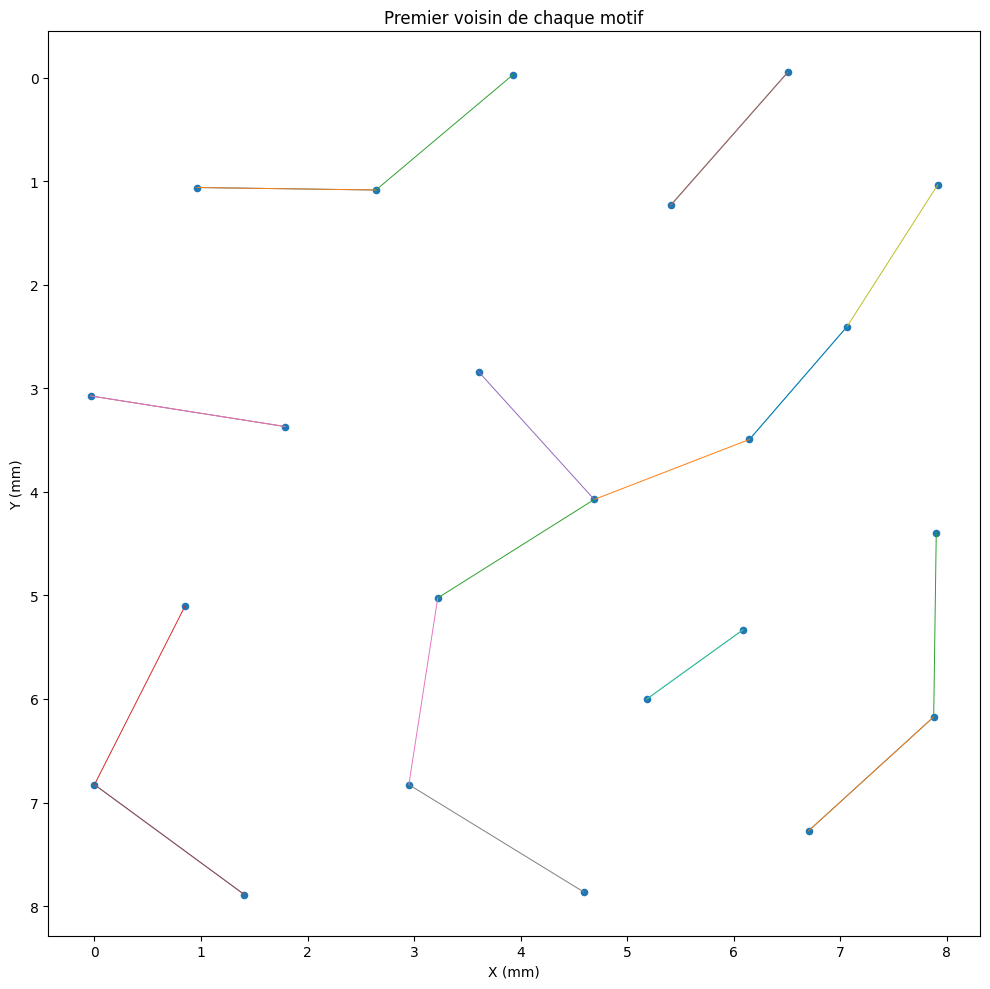

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# Modifier les noms des fichiers si nécessaire
fichier_points = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Resultssimu.csv"
fichier_ovales = "C:/Users/lisab/OneDrive - INSA Toulouse/Documents/insa/stage 4A/Data/Resultscerclesimu.csv"

points = pd.read_csv(fichier_points)
ovales = pd.read_csv(fichier_ovales)




# Diamètre équivalent à partir de l'aire
# D_eq = 2 * sqrt(A/pi)
diametre_equivalent = 2 * np.sqrt(ovales["Area"] / np.pi)

print("TAILLE DES MOTIFS")

print(f"\nDiamètre équivalent moyen :")
print(f"  {diametre_equivalent.mean():.2f} mm")
print(f"  écart-type = {diametre_equivalent.std():.2f} mm")



# Coordonnées des centres
xy = points[["X", "Y"]].values

# Création de l'arbre de recherche
tree = cKDTree(xy)

# k=2 :
#   résultat 0 = le point lui-même
#   résultat 1 = son premier voisin
distances, indices = tree.query(xy, k=2)

# Distance vers le premier voisin
premier_voisin = distances[:, 1]


print(f"\nEspacement moyen :")
print(f"  {premier_voisin.mean():.2f} mm")

print(f"Écart-type = {premier_voisin.std():.2f} mm ")




image = None

plt.figure(figsize=(10, 10))

if image is not None:
    plt.imshow(image, cmap="gray")

# Affichage des centres
plt.scatter(
    xy[:, 0],
    xy[:, 1],
    s=20
)

# Tracé des connexions vers le premier voisin
for i, (x, y) in enumerate(xy):

    j = indices[i, 1]

    x2, y2 = xy[j]

    plt.plot(
        [x, x2],
        [y, y2],
        linewidth=0.7
    )

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Premier voisin de chaque motif")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()